# Epydemix Exercise — SOLUTION: Modeling an Epidemic with Population Data and Interventions

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ngozzi/computational-epidemiology/blob/main/notebooks/epydemix/epydemix_solution.ipynb)

This notebook contains the complete solution to the Epydemix exercise.

If you are running this on Google Colab, install the required packages first:

In [1]:
import sys, os, subprocess
if "google.colab" in sys.modules or os.getenv("COLAB_RELEASE_TAG"):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    "https://raw.githubusercontent.com/epistorm/epydemix/refs/heads/main/tutorials/colab_requirements.txt"])

## Part 1: Defining and Simulating an SEIR Model

**Virus-X** follows SEIR dynamics:

$$S \xrightarrow{\beta \cdot I} E \xrightarrow{\sigma} I \xrightarrow{\gamma} R$$

Parameters: $\beta = 0.04$, $\sigma = 1/5$, $\gamma = 1/7$

### Task 1.1 — Define the SEIR model

In [10]:
from epydemix import EpiModel

seir_model = EpiModel(
    name='SEIR Model - Virus-X',
    compartments=['S', 'E', 'I', 'R'],
)

# S -> E: mediated by I at rate beta
seir_model.add_transition(source='S', target='E', params=(0.35, 'I'), kind='mediated')

# E -> I: spontaneous at rate sigma = 1/5
seir_model.add_transition(source='E', target='I', params=1/5, kind='spontaneous')

# I -> R: spontaneous at rate gamma = 1/7
seir_model.add_transition(source='I', target='R', params=1/7, kind='spontaneous')

print(seir_model)

EpiModel(name='SEIR Model - Virus-X')
Compartments: 4
  S, E, I, R
Transitions: 3
  Transitions between compartments:
    S -> E, params: (0.35, 'I') (kind: mediated)
    E -> I, params: 0.2 (kind: spontaneous)
    I -> R, params: 0.14285714285714285 (kind: spontaneous)
Parameters: 0
  No parameters defined
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



### Task 1.2 — Run simulations

In [11]:
# Default population has 100,000 individuals
default_N = 100_000

seir_results = seir_model.run_simulations(
    start_date="2024-01-01",
    end_date="2024-06-30",
    Nsim=100,
    percentage_in_agents=20 / default_N
)

### Task 1.3 — Plot compartment quantiles

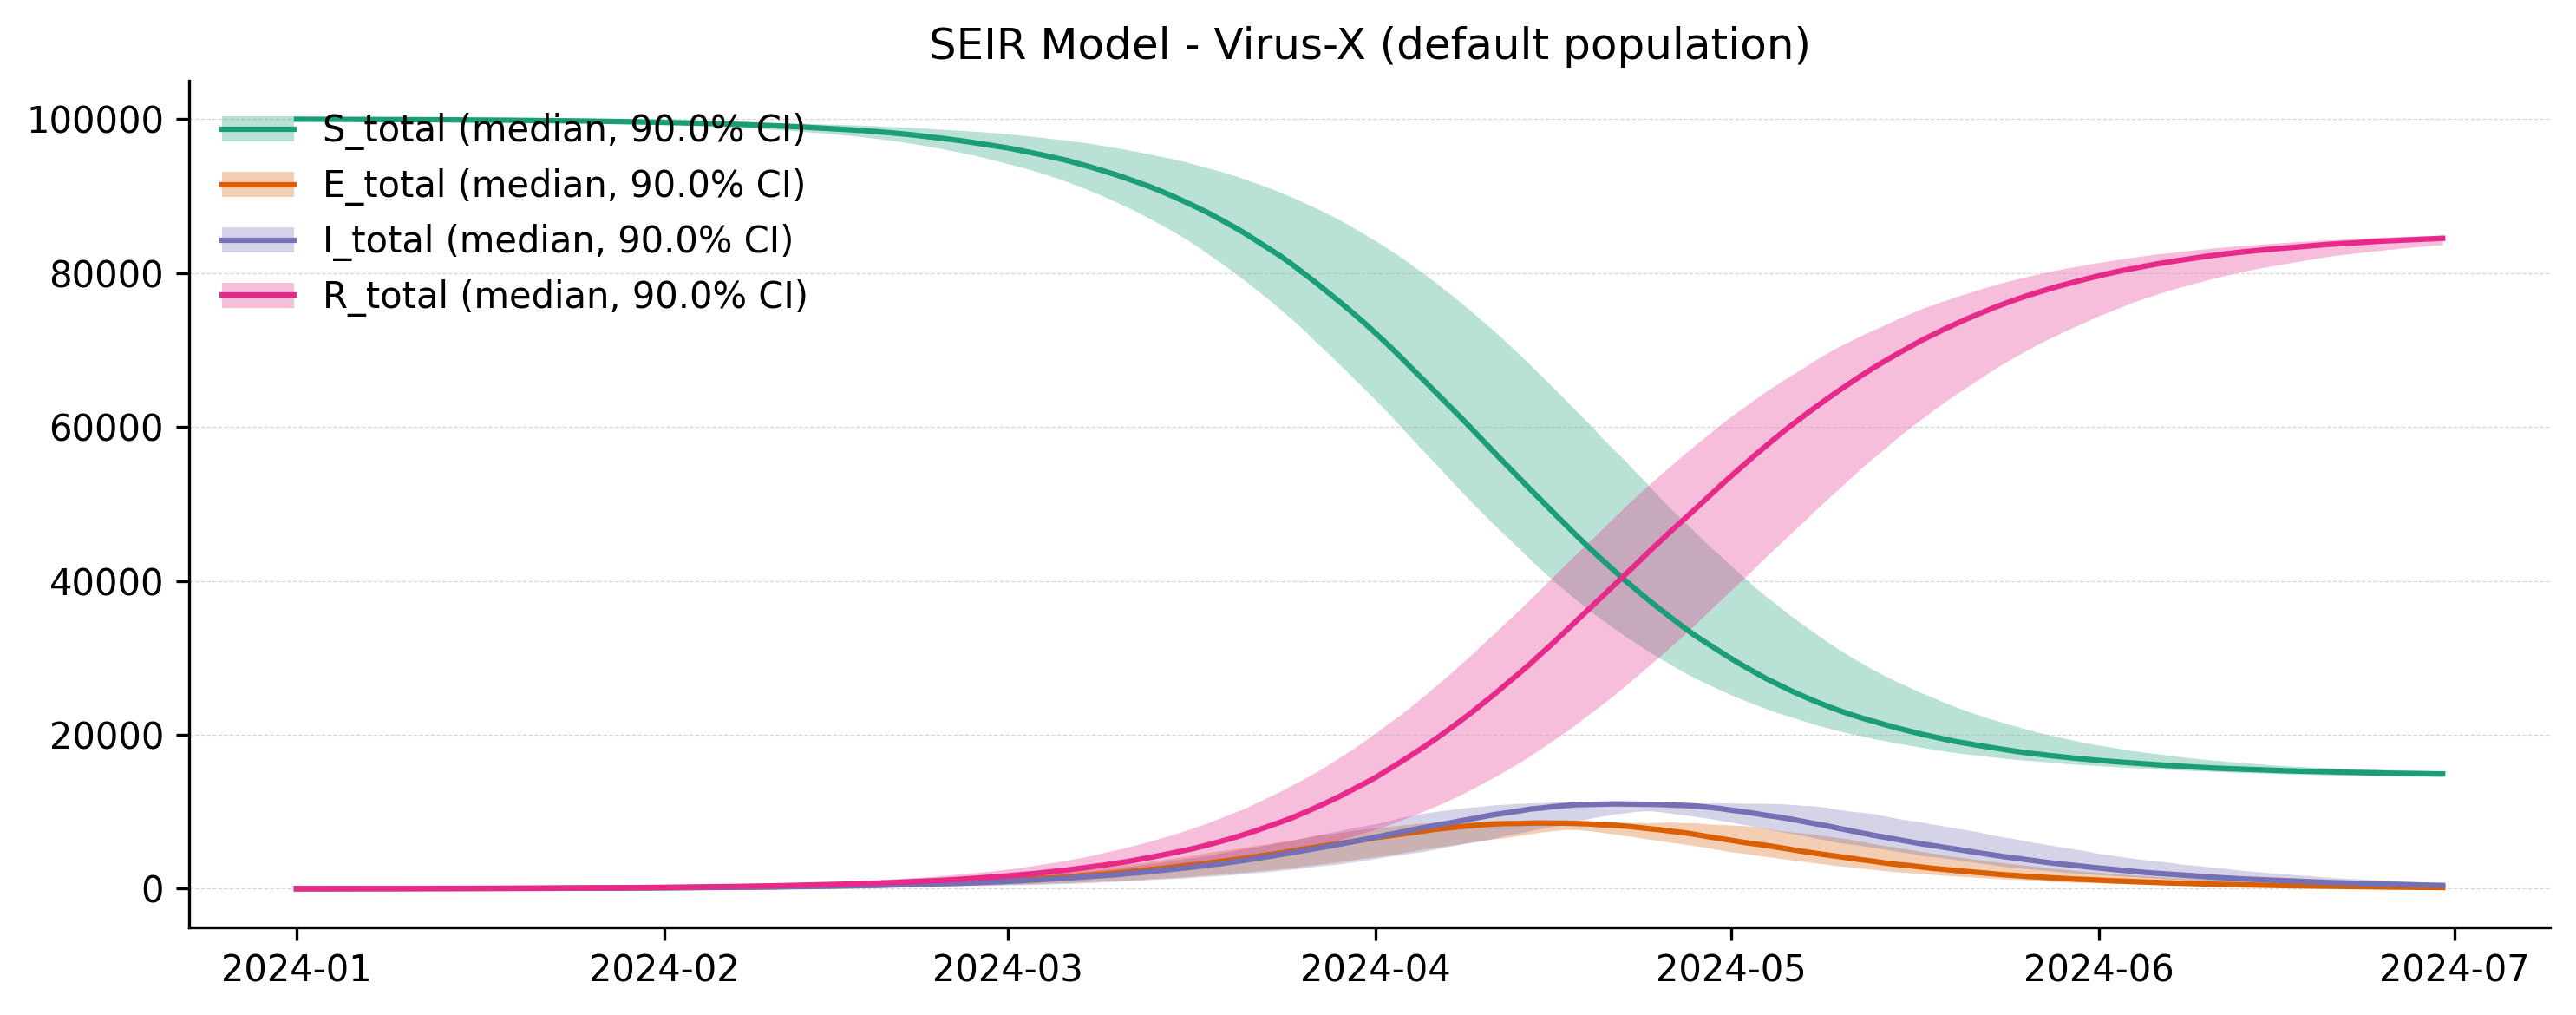

In [9]:
from epydemix.visualization import plot_quantiles

df_quantiles = seir_results.get_quantiles_compartments()
ax = plot_quantiles(df_quantiles,
                    columns=["S_total", "E_total", "I_total", "R_total"],
                    title='SEIR Model - Virus-X (default population)')

### Task 1.4 — Plot daily new exposures (incidence)

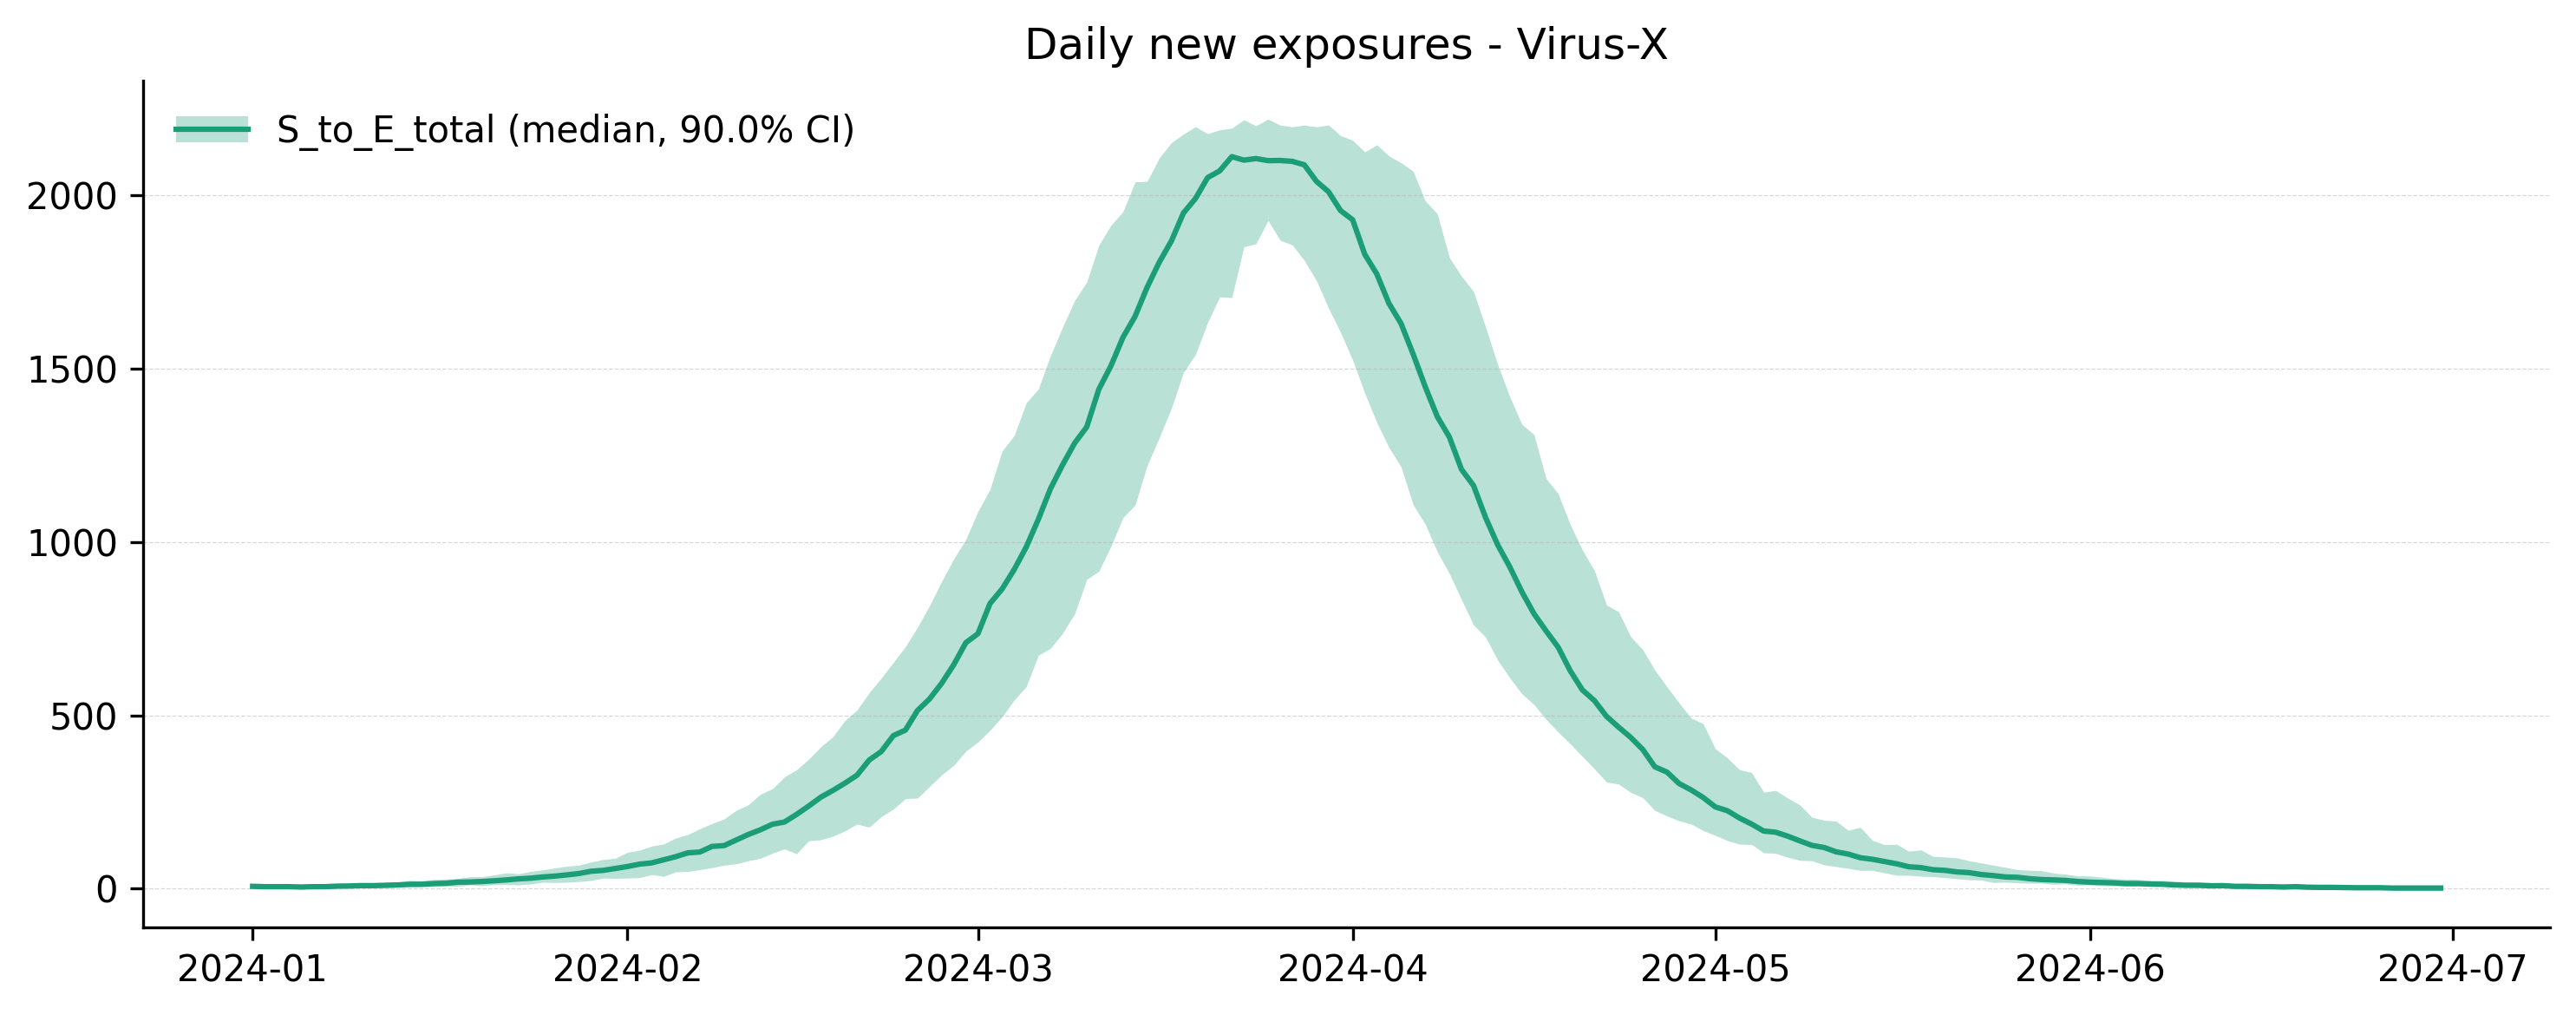

In [12]:
df_transitions = seir_results.get_quantiles_transitions()
ax = plot_quantiles(df_transitions,
                    columns=["S_to_E_total"],
                    title='Daily new exposures - Virus-X')

---

## Part 2: Modeling with Real Population Data

### Task 2.1 — Load population objects

In [1]:
from epydemix.population import load_epydemix_population

population_italy = load_epydemix_population("Italy")
print(population_italy)

Population(name='Italy')
Demographic groups: 5 groups
Population distribution:
  - 0-4: 2042699 individuals
  - 5-19: 7997107 individuals
  - 20-49: 20936936 individuals
  - 50-64: 13953616 individuals
  - 65+: 14504782 individuals
Contact matrices: 4 layers
Available layers:
  - school
  - work
  - home
  - community



### Task 2.2 — Visualize Italy's contact matrices

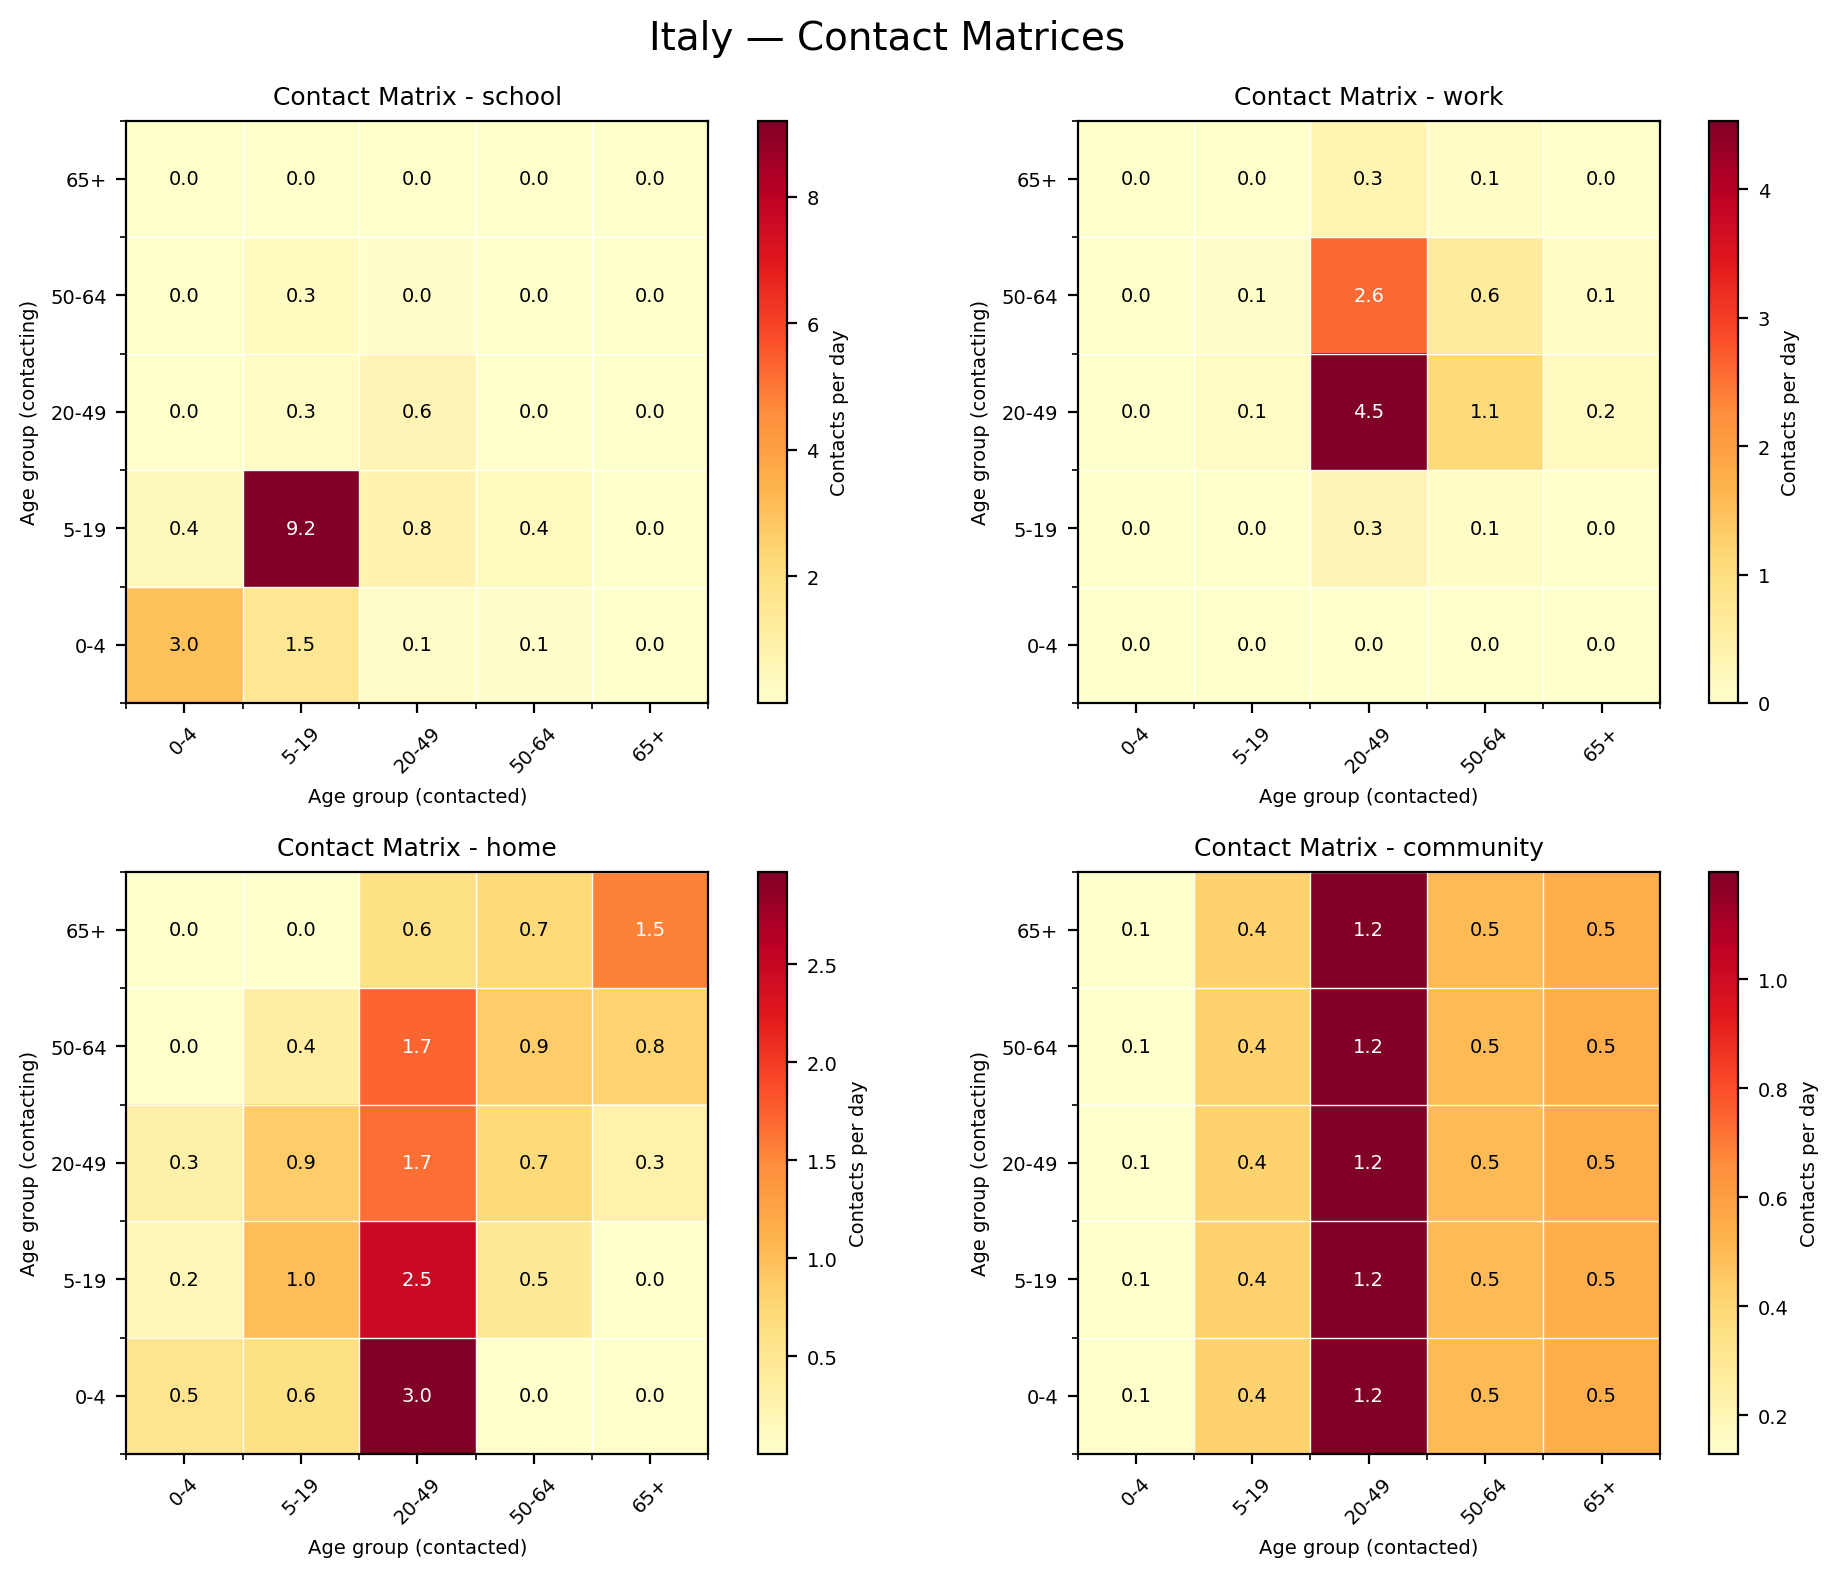

In [2]:
from epydemix.visualization import plot_contact_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=2, dpi=200, figsize=(10, 8))
plot_contact_matrix(population_italy, "school",    ax=axes[0, 0], fontsize=7, show_values=True)
plot_contact_matrix(population_italy, "work",      ax=axes[0, 1], fontsize=7, show_values=True)
plot_contact_matrix(population_italy, "home",      ax=axes[1, 0], fontsize=7, show_values=True)
plot_contact_matrix(population_italy, "community", ax=axes[1, 1], fontsize=7, show_values=True)
plt.suptitle("Italy — Contact Matrices", fontsize=14)
plt.tight_layout()

### Task 2.3 — Run SEIR simulations for Italy

In [4]:
from epydemix import load_predefined_model

# --- Italy ---
model_italy = load_predefined_model("SEIR", transmission_rate=0.04, recovery_rate=1/7, incubation_rate=1/5)
model_italy.set_population(population_italy)

results_italy = model_italy.run_simulations(
    start_date="2024-01-01",
    end_date="2024-09-30",
    Nsim=100,
    percentage_in_agents=100 / model_italy.population.Nk.sum()
)

### Task 2.4 — Plot curves

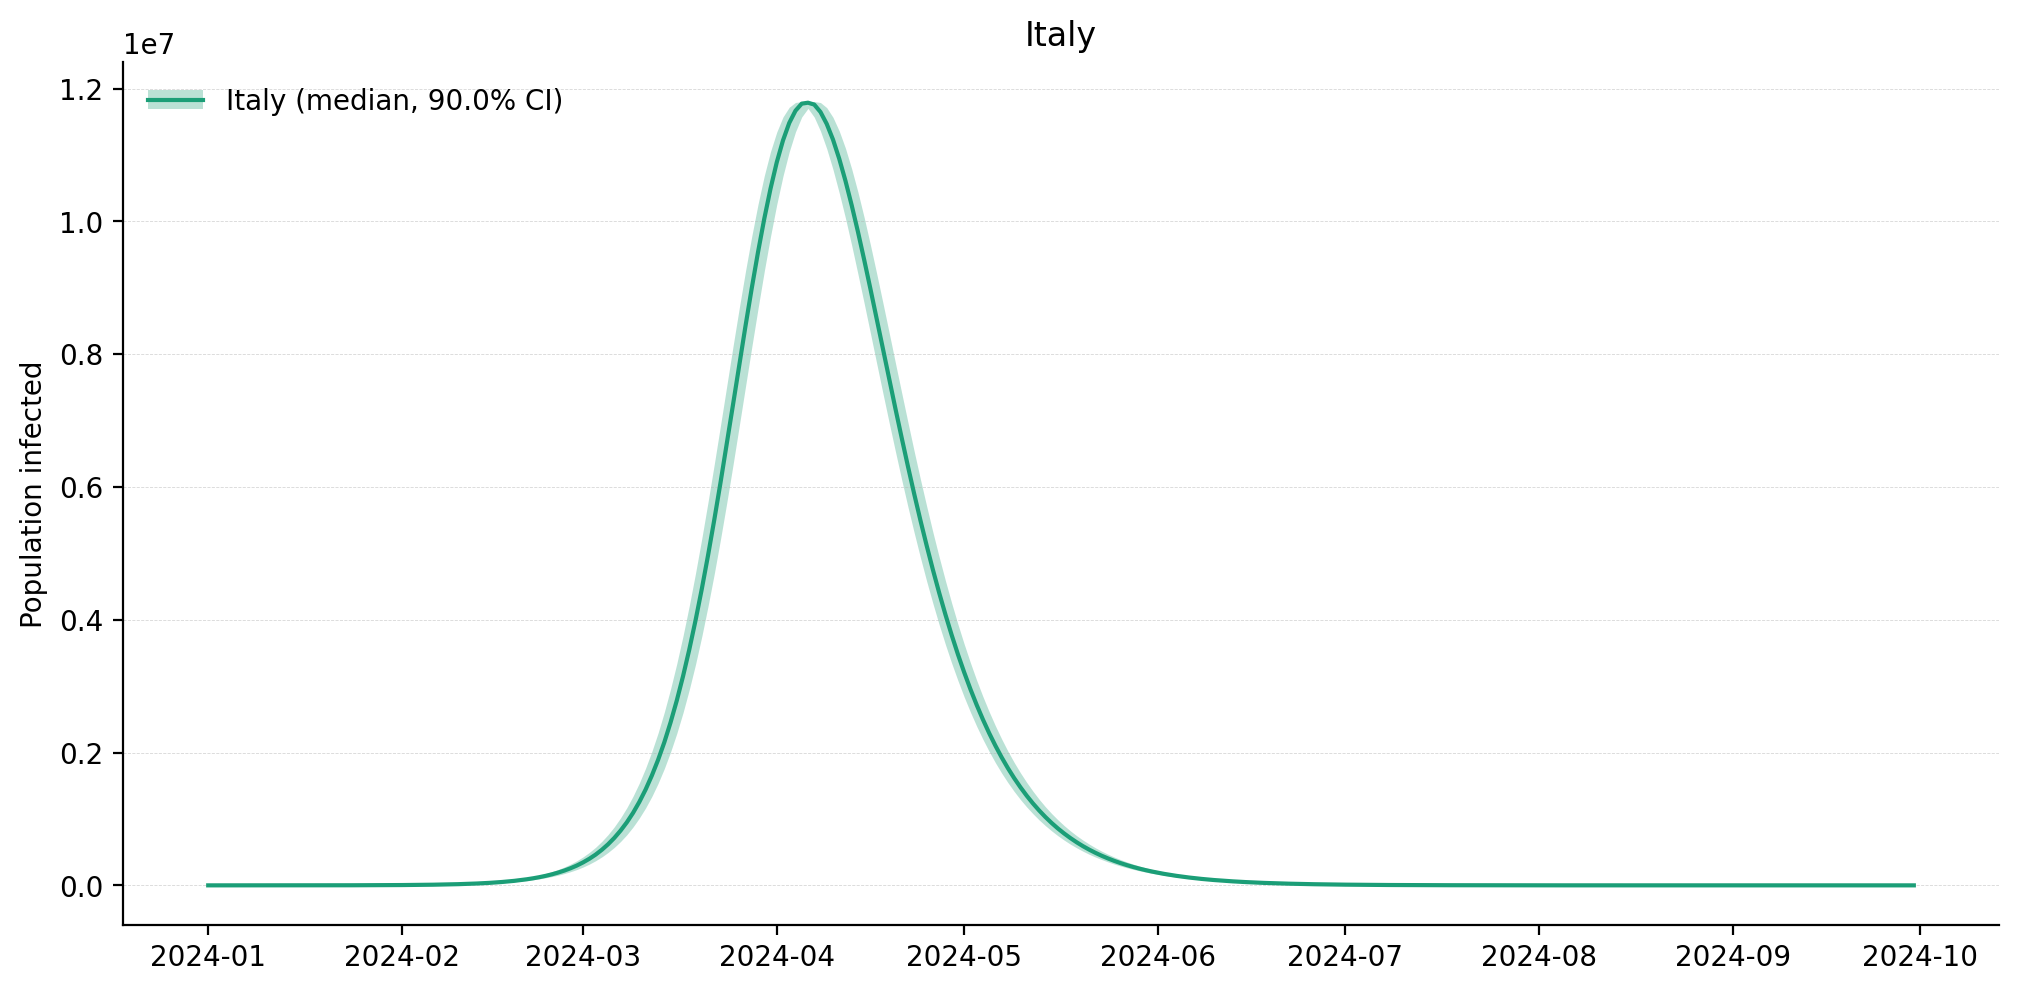

In [10]:
import seaborn as sns
import numpy as np
colors = sns.color_palette("Dark2")

df_italy = results_italy.get_quantiles_compartments()
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

ax = plot_quantiles(df_italy, columns=["Infected_total"], colors=colors[0], labels="Italy", ax=ax)
ax.set_ylabel("Population infected")
ax.set_title("Italy")
plt.show()

The attack rate difference reflects the distinct age structures and contact patterns of Italy and Kenya. Kenya's younger, more contact-active population tends to produce higher attack rates for the same disease parameters.

---

## Part 3: Modeling Non-Pharmaceutical Interventions

### Task 3.1 — Create SEIR model for Italy with interventions

In [21]:
model_italy_npi = load_predefined_model("SEIR", transmission_rate=0.04, recovery_rate=1/7, incubation_rate=1/5)
model_italy_npi.set_population(population_italy)

# 1. School closure: 80% reduction in school contacts
model_italy_npi.add_intervention(
    layer_name="school",
    start_date="2024-02-01",
    end_date="2024-03-15",
    reduction_factor=0.2,
    name="school closure"
)

# 2. Workplace reduction: 50% reduction in work contacts
model_italy_npi.add_intervention(
    layer_name="work",
    start_date="2024-02-15",
    end_date="2024-04-30",
    reduction_factor=0.5,
    name="workplace reduction"
)

# 3. Masking + distancing: reduce transmission rate
model_italy_npi.override_parameter(
    start_date="2024-02-01",
    end_date="2024-09-30",
    parameter_name="transmission_rate",
    value=0.025
)

### Task 3.2 — Visualize spectral radius over time

<Axes: title={'center': 'Contact Pattern Intensity - Overall Layer'}, xlabel='Date', ylabel='Change in spectral radius (%)'>

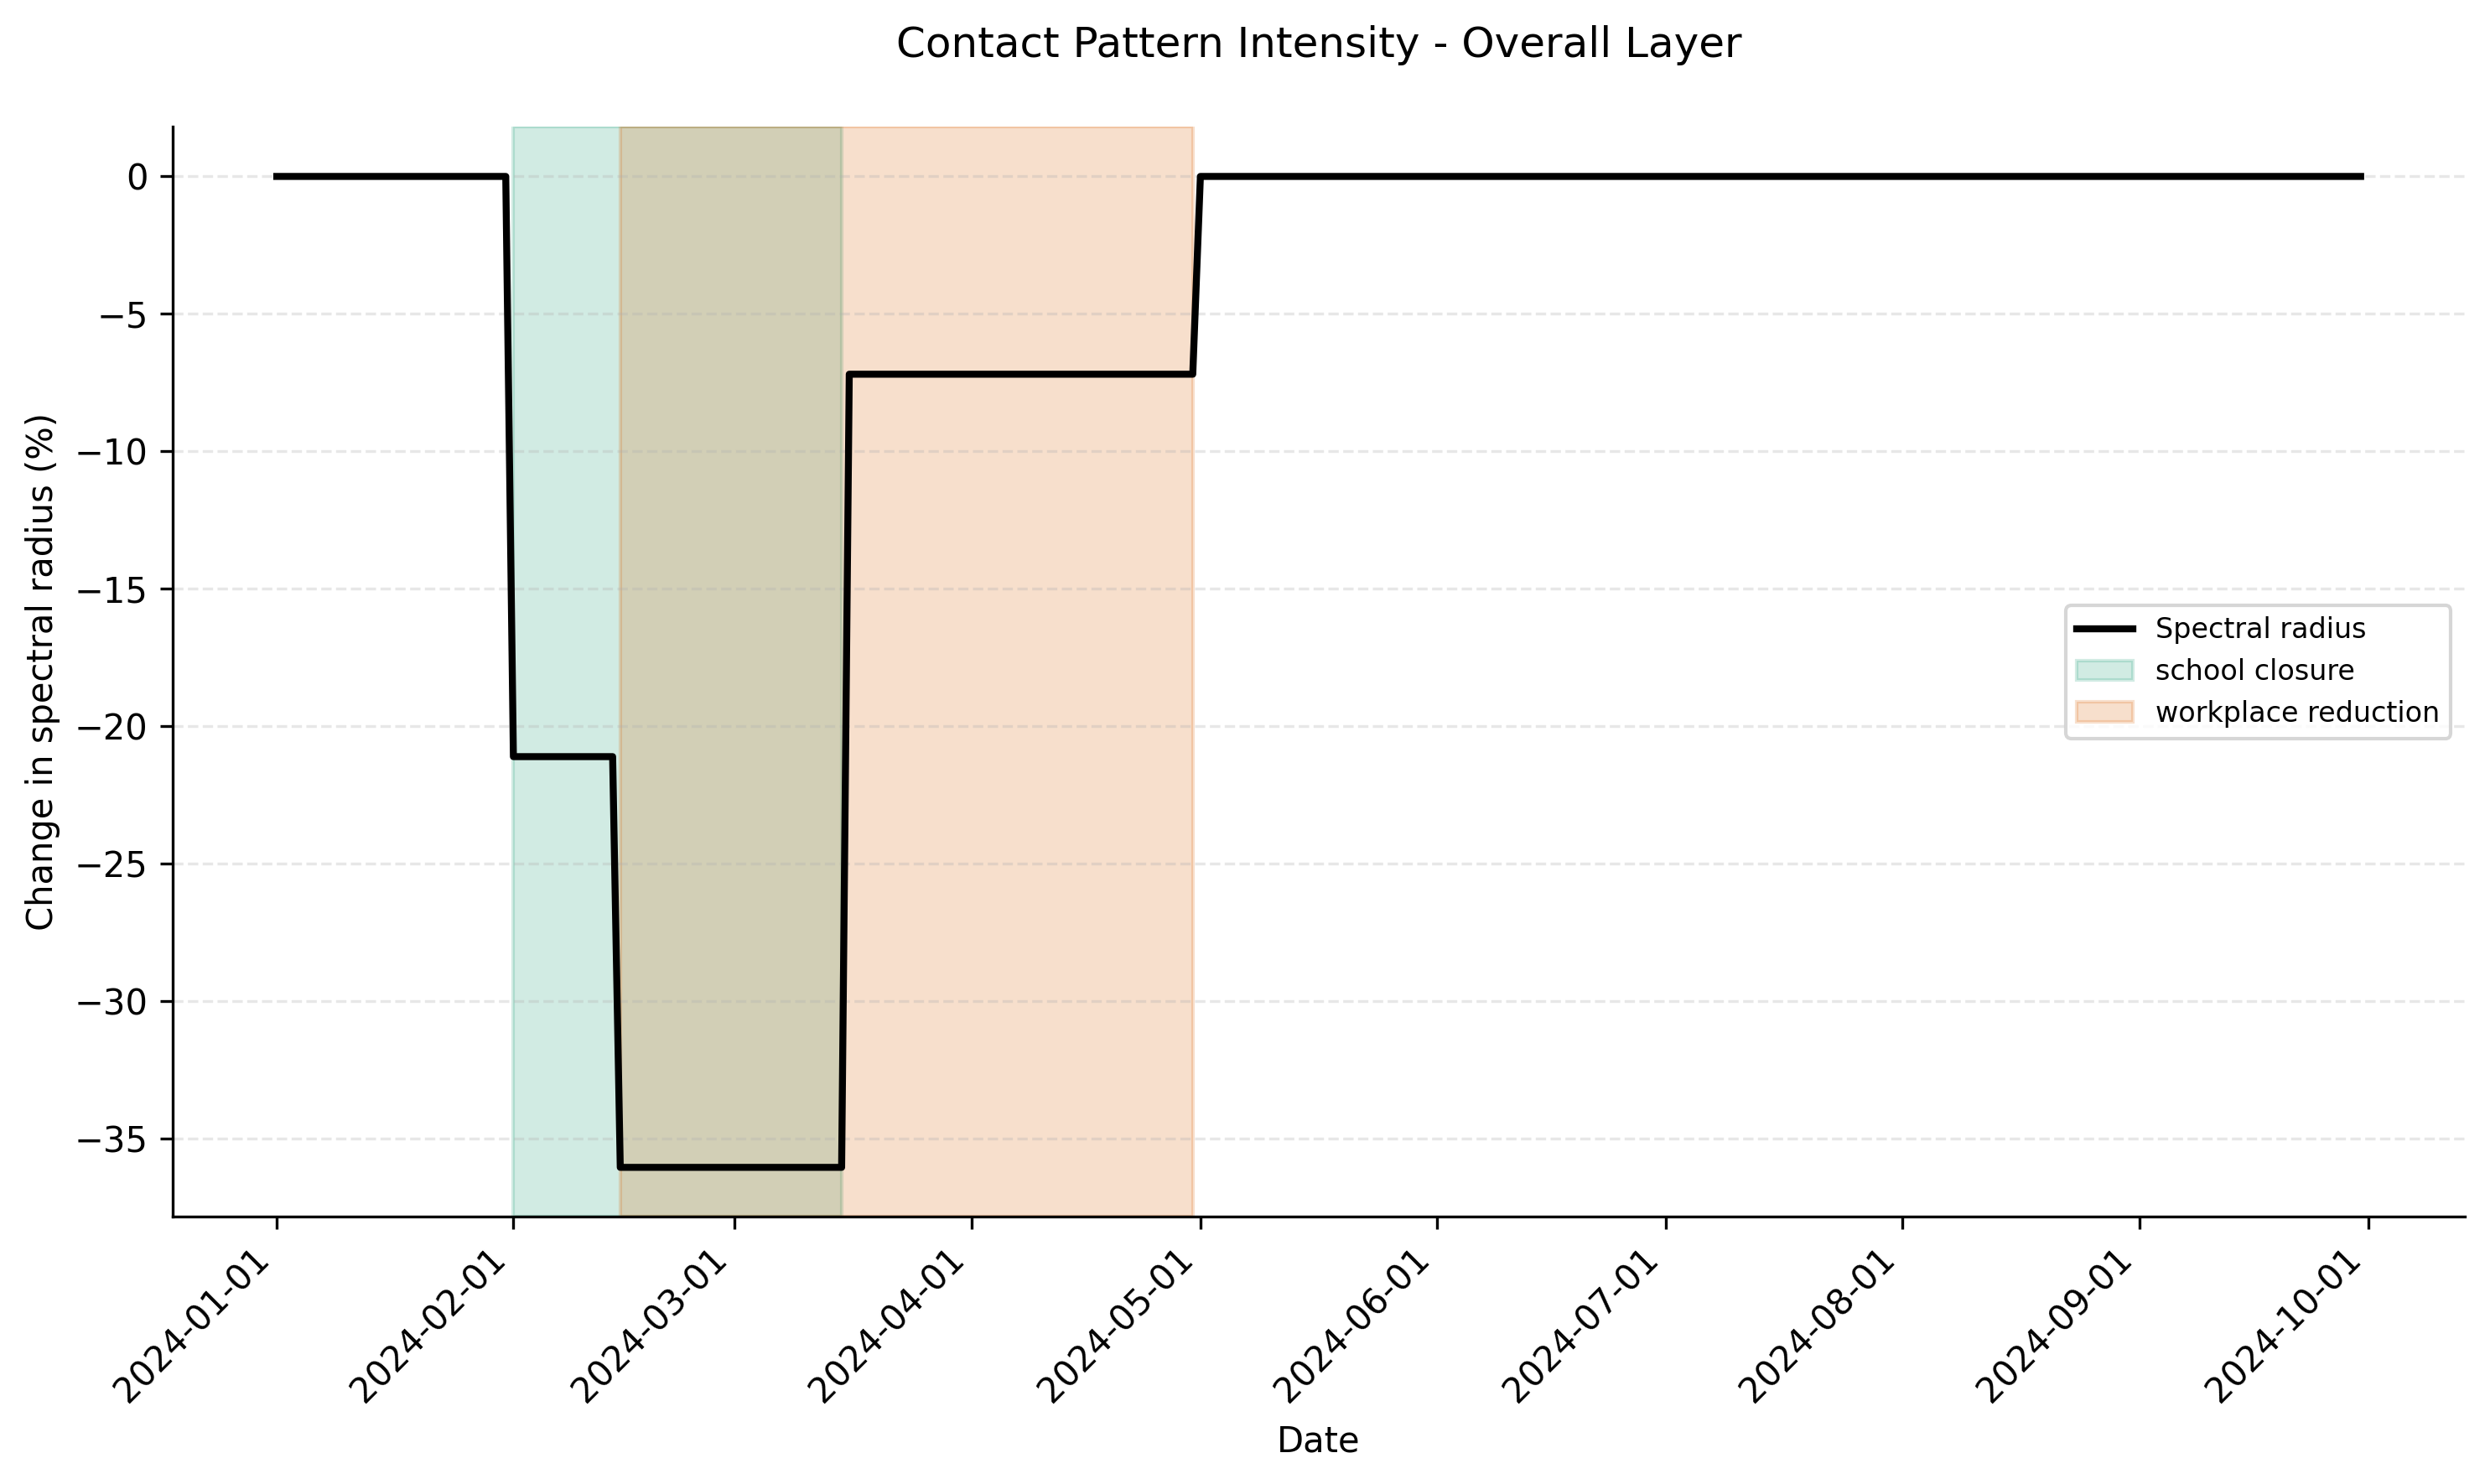

In [22]:
from epydemix.visualization import plot_spectral_radius
from epydemix.utils import compute_simulation_dates

simulation_dates = compute_simulation_dates("2024-01-01", "2024-09-30")
model_italy_npi.compute_contact_reductions(simulation_dates)

plot_spectral_radius(model_italy_npi, legend_loc="center right", show_perc=True)

The spectral radius drops sharply when interventions are active, indicating a reduced transmission potential. The combined school and workplace closures produce a larger reduction than either alone.

### Task 3.3 — Run simulations with interventions

In [23]:
results_italy_npi = model_italy_npi.run_simulations(
    start_date="2024-01-01",
    end_date="2024-09-30",
    Nsim=100,
    percentage_in_agents=100 / model_italy_npi.population.Nk.sum()
)

### Task 3.4 — Compare Italy with vs. without interventions

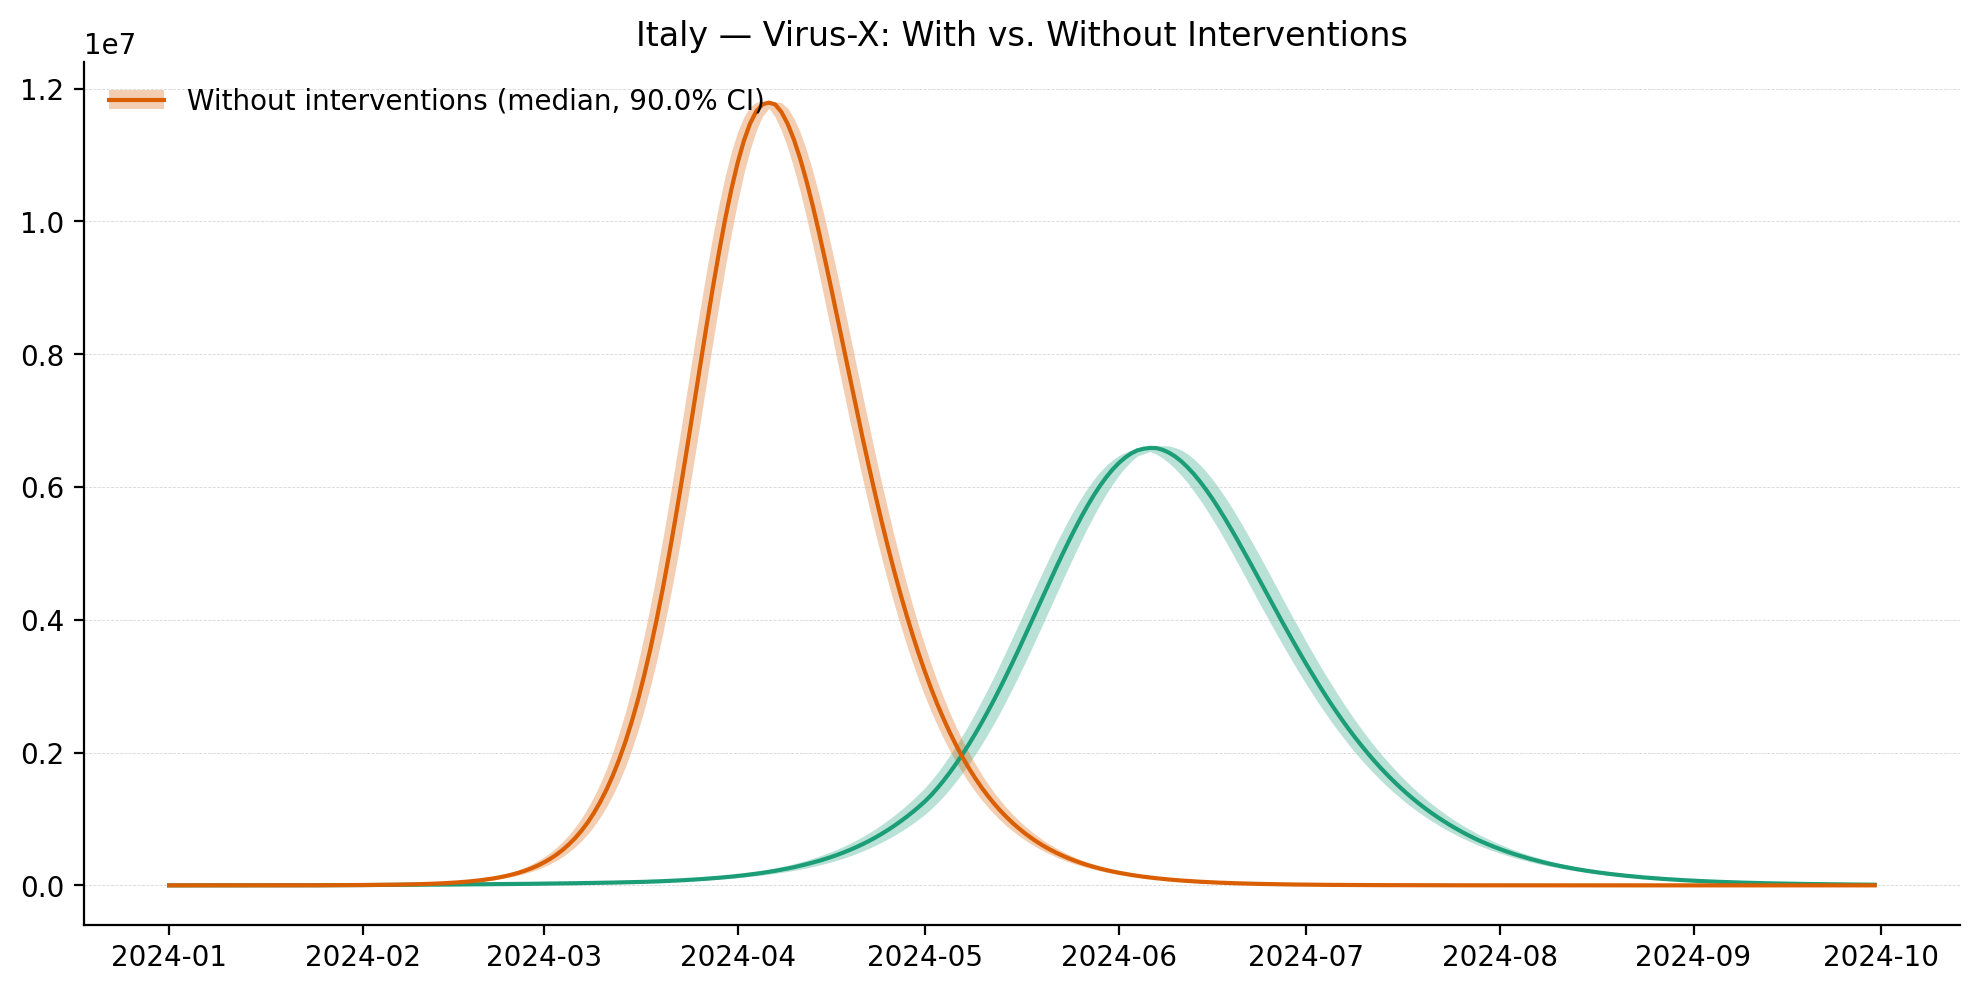

In [24]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

df_npi = results_italy_npi.get_quantiles_compartments()
df_baseline = results_italy.get_quantiles_compartments()

ax = plot_quantiles(df_npi,      columns=["Infected_total"], colors=colors[0], labels="With interventions",    ax=ax)
ax = plot_quantiles(df_baseline, columns=["Infected_total"], colors=colors[1], labels="Without interventions", ax=ax)

ax.set_title("Italy — Virus-X: With vs. Without Interventions")
plt.show()

### Task 3.5 — Quantify intervention effectiveness

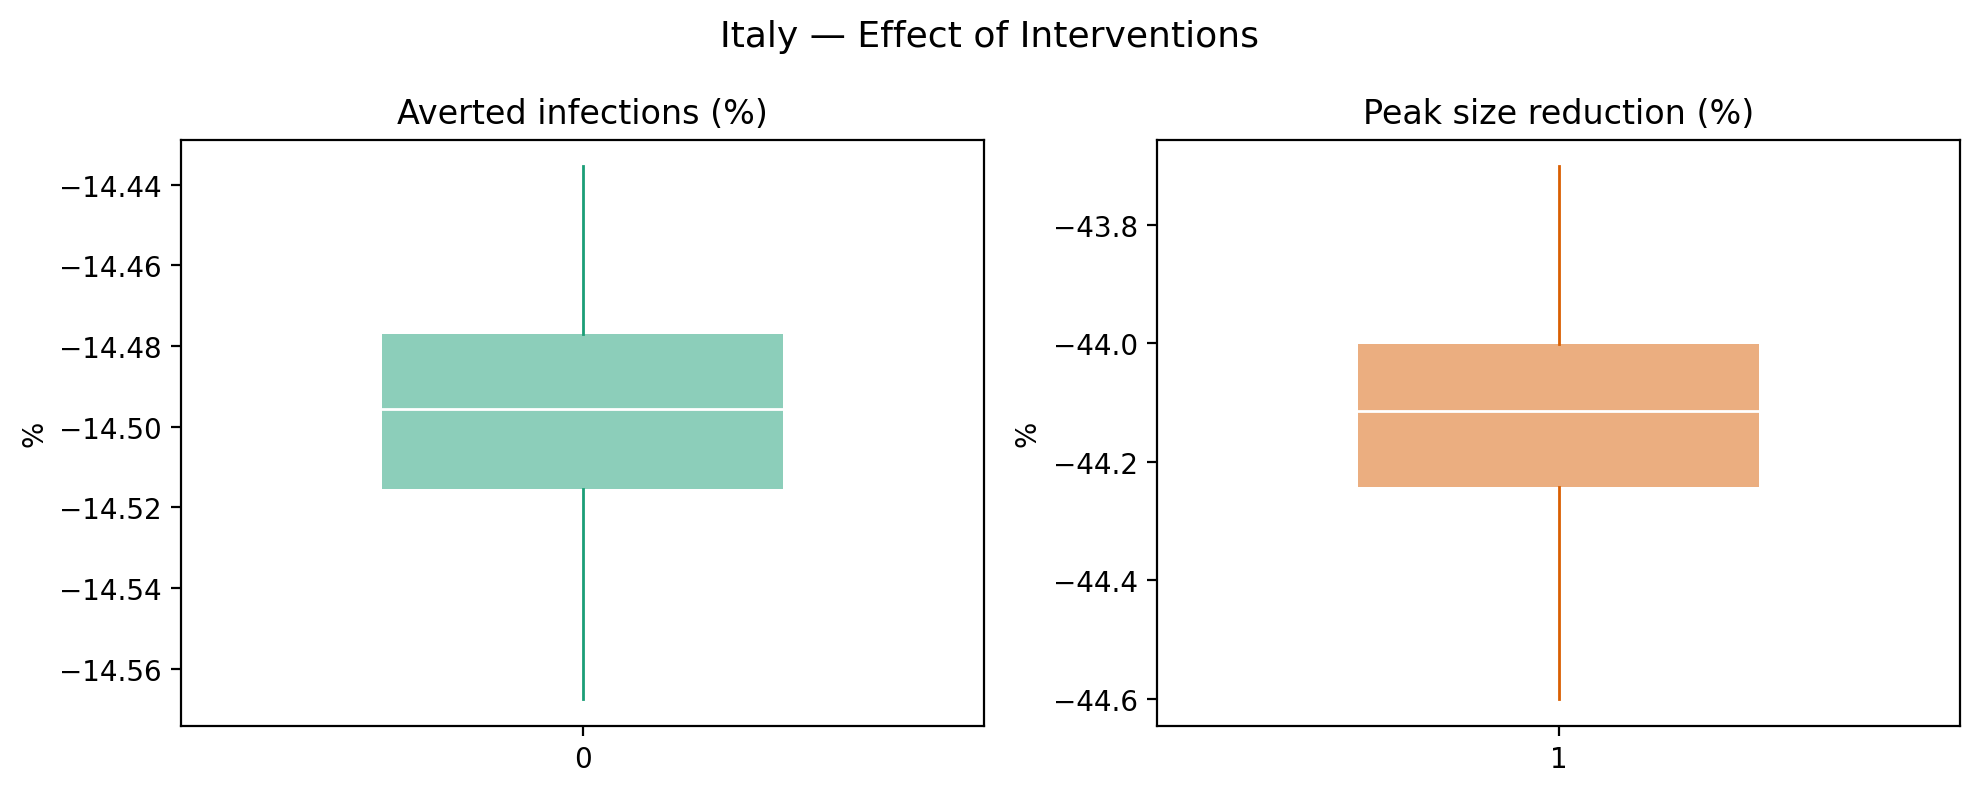

Averted infections: -14.5% (median)
Peak size reduction: -44.1% (median)


In [25]:
traj_italy_npi      = results_italy_npi.get_stacked_compartments()
traj_italy_baseline = results_italy.get_stacked_compartments()

# Averted infections: % change in total recovered (attack rate proxy)
ar_npi      = traj_italy_npi["Recovered_total"][:, -1]
ar_baseline = traj_italy_baseline["Recovered_total"][:, -1]
averted_infections_perc = 100 * (ar_npi - ar_baseline) / ar_baseline  # negative = reduction

# Peak size reduction: % change in peak infected
peak_npi      = traj_italy_npi["Infected_total"].max(axis=1)
peak_baseline = traj_italy_baseline["Infected_total"].max(axis=1)
delta_peak_perc = 100 * (peak_npi - peak_baseline) / peak_baseline  # negative = reduction

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), dpi=200)

axes[0].boxplot(averted_infections_perc, positions=[0], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=colors[0], alpha=0.5, linewidth=0),
                medianprops=dict(color="white"),
                whiskerprops=dict(color=colors[0]), showfliers=False, showcaps=False)

axes[1].boxplot(delta_peak_perc, positions=[1], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=colors[1], alpha=0.5, linewidth=0),
                medianprops=dict(color="white"),
                whiskerprops=dict(color=colors[1]), showfliers=False, showcaps=False)

axes[0].set_title("Averted infections (%)")
axes[0].set_ylabel("%")
axes[1].set_title("Peak size reduction (%)")
axes[1].set_ylabel("%")
plt.suptitle("Italy — Effect of Interventions", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Averted infections: {np.median(averted_infections_perc):.1f}% (median)")
print(f"Peak size reduction: {np.median(delta_peak_perc):.1f}% (median)")